In [2]:
# ================================
# INSTALL
# ================================
!pip install networkx pandas numpy

# ================================
# IMPORTS
# ================================
import networkx as nx
import pandas as pd
import numpy as np
import random

random.seed(42)
np.random.seed(42)
# ================================
# CONFIG
# ================================
NUM_NODES = 60
NUM_TRANSACTIONS = 3000
MAX_PATHS = 5
MAX_HOPS = 5

# ================================
# GRAPH
# ================================
G = nx.barabasi_albert_graph(NUM_NODES, 3)

for u, v in G.edges():
    G[u][v]['capacity'] = random.randint(100, 1000)
    G[u][v]['balance'] = random.randint(20, 500)
    G[u][v]['fee'] = random.uniform(0.1, 2.0)
    G[u][v]['congestion'] = random.uniform(0, 1)
    G[u][v]['success_rate'] = random.uniform(0.5, 1.0)

# ================================
# SIGMOID
# ================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ================================
# DATA GENERATION
# ================================
dataset = []
transaction_id = 0

for _ in range(NUM_TRANSACTIONS):

    nodes = list(G.nodes())
    s, d = random.sample(nodes, 2)
    amount = random.randint(5, 200)

    try:
        paths = list(nx.all_simple_paths(G, s, d, cutoff=MAX_HOPS))[:MAX_PATHS]
    except:
        continue

    for path in paths:

        balances, capacities, fees, congestions, success_rates = [], [], [], [], []

        for i in range(len(path)-1):
            edge = G[path[i]][path[i+1]]
            balances.append(edge['balance'])
            capacities.append(edge['capacity'])
            fees.append(edge['fee'])
            congestions.append(edge['congestion'])
            success_rates.append(edge['success_rate'])

        if not balances:
            continue

        # -------- FEATURES --------
        num_hops = len(path)-1
        min_balance = min(balances)
        min_capacity = min(capacities)

        routing_fee = sum(fees)
        avg_congestion = np.mean(congestions)
        past_success_rate = np.mean(success_rates)

        min_liquidity_ratio = min_balance / (min_capacity + 1e-6)
        path_reliability = past_success_rate * (1 - avg_congestion)

        # -------- ECONOMIC --------
        liquidity_lock_cost = amount * random.uniform(0.01, 0.05)
        expected_profit = routing_fee - liquidity_lock_cost
        risk_factor = random.uniform(0, 1)

        # -------- SUCCESS (BEST VERSION) --------
        score = (
            1.5 * min_liquidity_ratio +
            1.2 * path_reliability -
            0.8 * avg_congestion -
            0.3 * (routing_fee / 10) -
            0.5 * risk_factor
        )

        bias = 0.35   # 🔥 THIS WAS KEY

        prob = sigmoid(score + bias)
        success = 1 if random.random() < prob else 0

        dataset.append([
            transaction_id, s, d, amount, num_hops,
            min_balance, routing_fee, avg_congestion,
            past_success_rate, min_liquidity_ratio,
            path_reliability, expected_profit,
            risk_factor, success
        ])

    transaction_id += 1

# ================================
# DATAFRAME
# ================================
columns = [
    'transaction_id','source','destination','transaction_amount',
    'num_hops','min_balance','routing_fee','network_congestion',
    'past_success_rate','min_liquidity_ratio','path_reliability',
    'expected_profit','risk_factor','success'
]

df = pd.DataFrame(dataset, columns=columns)

print(df.shape)
print(df['success'].value_counts(normalize=True))

df.to_csv("hspr_pcn_dataset.csv", index=False)

from google.colab import files
files.download("hspr_pcn_dataset.csv")

(14995, 14)
success
1    0.618339
0    0.381661
Name: proportion, dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Model Comparison ===

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.624208   0.645342  0.870550  0.741217  0.635110
1        Random Forest  0.594198   0.673759  0.666127  0.669921  0.621760
2              XGBoost  0.614538   0.650172  0.814995  0.723313  0.615343

=== Cross Validation (Random Forest) ===
CV Accuracy: 0.5999333111037013

Top Features:

                 Feature  Importance
10  liquidity_congestion    0.109730
6    min_liquidity_ratio    0.108712
12         risk_adjusted    0.092323
9            risk_factor    0.090106
8        expected_profit    0.080658
7       path_reliability    0.080281
4     network_congestion    0.079295
5      past_success_rate    0.077919
0     transaction_amount    0.075272
3            routing_fee    0.071730


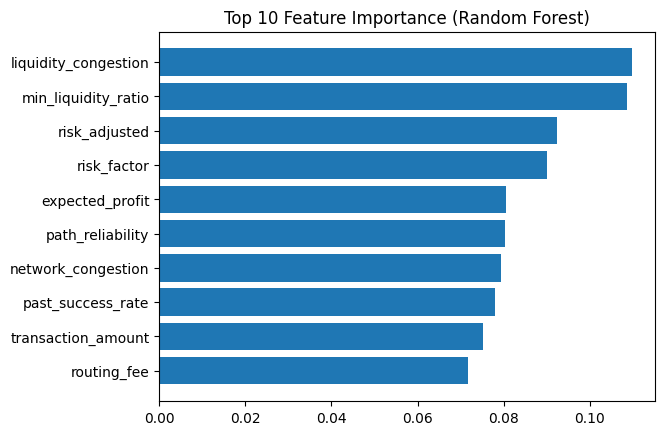

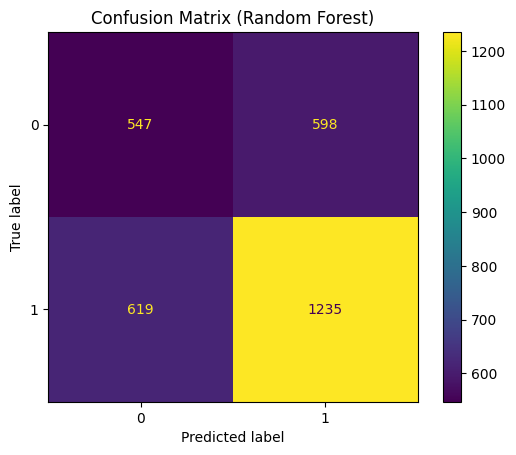

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ================================
# INSTALL
# ================================
!pip install scikit-learn xgboost pandas matplotlib

# ================================
# IMPORTS
# ================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("hspr_pcn_dataset.csv")

# ================================
# FEATURES
# ================================
X = df.drop(columns=['success','transaction_id','source','destination'])
y = df['success']

# IMPORTANT FEATURE ENGINEERING
X['liquidity_congestion'] = X['min_liquidity_ratio'] * X['network_congestion']
X['fee_per_hop'] = X['routing_fee'] / (X['num_hops'] + 1)
X['risk_adjusted'] = X['path_reliability'] / (1 + X['risk_factor'])

# ================================
# SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ================================
# SCALING
# ================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ================================
# MODELS (BEST CONFIG)
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=15,
        min_samples_split=4,
        class_weight='balanced',
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
}

# ================================
# TRAIN & EVALUATE
# ================================
results = []

for name, model in models.items():

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]


    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, f1, roc])


# RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"
])

print("\n=== Model Comparison ===\n")
print(results_df)

from sklearn.model_selection import cross_val_score

rf_model = models["Random Forest"]

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("\n=== Cross Validation (Random Forest) ===")
print("CV Accuracy:", cv_scores.mean())

# ================================
# SAVE RESULTS
# ================================
results_df.to_csv("model_results.csv", index=False)

# ================================
# FEATURE IMPORTANCE (RF)
# ================================
rf_model = models["Random Forest"]

importances = rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n")
print(feat_df.head(10))

# Plot
plt.figure()
plt.barh(feat_df["Feature"][:10], feat_df["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

# ================================
# CONFUSION MATRIX (RF)
# ================================
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model, X_test, y_test
)
plt.title("Confusion Matrix (Random Forest)")
plt.show()

# ================================
# DOWNLOAD RESULTS (COLAB)
# ================================
from google.colab import files
files.download("model_results.csv")

In [4]:
def compute_utility(row, prob):
    """
    Expected utility formulation (research-level)
    """

    profit = row['expected_profit']
    risk = row['risk_factor']

    # Expected loss (failure scenario)
    loss = profit * risk

    # Expected utility
    utility = prob * profit - (1 - prob) * loss

    return utility

In [9]:
import numpy as np
import random

def simulate_privacy_cost(path_length):
    """
    Privacy cost = latency + information leakage
    """

    # Latency grows linearly
    latency = 0.1 * path_length

    # Information leakage (log-based growth)
    leakage = np.log(1 + path_length)

    alpha, beta = 0.6, 0.4

    privacy_cost = alpha * latency + beta * leakage

    return privacy_cost, latency

In [10]:
import numpy as np

def select_best_path(paths_df):

    probs = rf_model.predict_proba(paths_df)[:, 1]

    utilities = []

    for i in range(len(paths_df)):

        row = paths_df.iloc[i]

        # 🔥 NEW utility
        utility = compute_utility(row, probs[i])

        # 🔥 NEW privacy model
        path_length = row['num_hops']
        privacy_cost, latency = simulate_privacy_cost(path_length)

        # adjust utility
        utility = utility - 0.2 * privacy_cost

        utilities.append(utility)

    utilities = np.array(utilities)

    # combine ML + utility
    scores = probs + 0.4 * utilities

    best_idx = np.argmax(scores)

    return best_idx, probs[best_idx], scores, probs

In [11]:
import joblib

joblib.dump(rf_model, "final_rf_model.pkl")
print("✅ Random Forest model saved as final_rf_model.pkl")

✅ Random Forest model saved as final_rf_model.pkl


In [12]:
# Take 5 candidate paths
sample_paths = X_test.sample(5).copy()

best_idx, best_prob, scores, all_probs = select_best_path(sample_paths)

print("\n=== ROUTING DECISION DEMO ===")
print("All Path Probabilities:", all_probs)
print("Best Path Index:", best_idx)
print("Best Path Probability:", best_prob)
print("Best Path Score:", scores[best_idx])
# print("Best Path Success Probability:", best_prob)


=== ROUTING DECISION DEMO ===
All Path Probabilities: [0.4585855  0.94583883 0.64249105 0.51329355 0.47811802]
Best Path Index: 2
Best Path Probability: 0.6424910527398332
Best Path Score: 1.1248341537925706


In [13]:
sample_paths['predicted_success_prob'] = all_probs
sample_paths.to_csv("routing_demo_results.csv", index=False)

print("✅ Routing demo saved as routing_demo_results.csv")

✅ Routing demo saved as routing_demo_results.csv


In [14]:
def manual_test():
    import pandas as pd

    print("\nEnter path details:\n")

    transaction_amount = float(input("Transaction amount: "))   # 🔥 ADD THIS
    num_hops = float(input("Number of hops: "))
    min_balance = float(input("Minimum balance: "))
    routing_fee = float(input("Routing fee: "))
    network_congestion = float(input("Network congestion (0-1): "))
    past_success_rate = float(input("Past success rate (0-1): "))
    min_liquidity_ratio = float(input("Liquidity ratio (0-1): "))
    path_reliability = float(input("Path reliability (0-1): "))
    expected_profit = float(input("Expected profit: "))
    risk_factor = float(input("Risk factor (0-1): "))

    data = pd.DataFrame([{
        'transaction_amount': transaction_amount,   # 🔥 ADD THIS
        'num_hops': num_hops,
        'min_balance': min_balance,
        'routing_fee': routing_fee,
        'network_congestion': network_congestion,
        'past_success_rate': past_success_rate,
        'min_liquidity_ratio': min_liquidity_ratio,
        'path_reliability': path_reliability,
        'expected_profit': expected_profit,
        'risk_factor': risk_factor
    }])

    # Feature engineering
    data['liquidity_congestion'] = data['min_liquidity_ratio'] * data['network_congestion']
    data['fee_per_hop'] = data['routing_fee'] / (data['num_hops'] + 1)
    data['risk_adjusted'] = data['path_reliability'] / (1 + data['risk_factor'])

    # Match training columns
    data = data[X.columns]

    prob = rf_model.predict_proba(data)[0][1]
    pred = rf_model.predict(data)[0]

    print("\n=== RESULT ===")
    print("Success Probability:", round(prob, 4))
    print("Prediction:", "SUCCESS" if pred == 1 else "FAILURE")




In [1]:
# Uncomment below to run interactive manual test (works in Colab terminal)
# manual_test()

In [15]:
import random

def simulate_privacy_cost(path_length):
    """
    Privacy cost = latency + information leakage
    """

    # Latency grows linearly
    latency = 0.1 * path_length

    # Information leakage (log-based growth)
    leakage = np.log(1 + path_length)

    alpha, beta = 0.6, 0.4

    privacy_cost = alpha * latency + beta * leakage

    return privacy_cost, latency

In [16]:
def create_features(paths):
    rows = []

    for path in paths:
        balances, capacities, fees, congestions, success_rates = [], [], [], [], []

        for i in range(len(path)-1):
            edge = G[path[i]][path[i+1]]
            balances.append(edge['balance'])
            capacities.append(edge['capacity'])
            fees.append(edge['fee'])
            congestions.append(edge['congestion'])
            success_rates.append(edge['success_rate'])

        if not balances:
            continue

        num_hops = len(path)-1
        min_balance = min(balances)
        routing_fee = sum(fees)
        avg_congestion = np.mean(congestions)
        past_success_rate = np.mean(success_rates)

        min_liquidity_ratio = min_balance / (min(capacities) + 1e-6)
        path_reliability = past_success_rate * (1 - avg_congestion)
        expected_profit = routing_fee - 0.2
        risk_factor = random.uniform(0, 1)

        rows.append({
            'transaction_amount': random.randint(5, 200),
            'num_hops': num_hops,
            'min_balance': min_balance,
            'routing_fee': routing_fee,
            'network_congestion': avg_congestion,
            'past_success_rate': past_success_rate,
            'min_liquidity_ratio': min_liquidity_ratio,
            'path_reliability': path_reliability,
            'expected_profit': expected_profit,
            'risk_factor': risk_factor
        })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    # Feature engineering (VERY IMPORTANT)
    df['liquidity_congestion'] = df['min_liquidity_ratio'] * df['network_congestion']
    df['fee_per_hop'] = df['routing_fee'] / (df['num_hops'] + 1)
    df['risk_adjusted'] = df['path_reliability'] / (1 + df['risk_factor'])

    return df

In [17]:
import networkx as nx
import random
import numpy as np

def shortest_path(G, s, d):
    try:
        return nx.shortest_path(G, s, d)
    except:
        return None

# def evaluate_path_dummy():
#     # simple simulation (for comparison)
#     return 1 if random.random() > 0.3 else 0


ml_success = []
sp_success = []
rand_success = []

for _ in range(300):

    s, d = random.sample(list(G.nodes()), 2)

    # ML routing
    paths = list(nx.all_simple_paths(G, s, d, cutoff=5))[:5]
    if len(paths) == 0:
        continue

    df_paths = create_features(paths)

    if len(df_paths) == 0:
        continue

    best_idx, _, _, _ = select_best_path(df_paths)

    ml_prob = rf_model.predict_proba(df_paths.iloc[[best_idx]])[0][1]
    ml_result = 1 if ml_prob > 0.5 else 0

    ml_success.append(ml_result)

    # Shortest path
    sp = shortest_path(G, s, d)

    if sp:
        sp_df = create_features([sp])

        if len(sp_df) > 0:
            sp_prob = rf_model.predict_proba(sp_df)[0][1]
            sp_result = 1 if sp_prob > 0.5 else 0

            sp_success.append(sp_result)

    # Random Path
    rp = random.choice(paths)

    rp_df = create_features([rp])

    if len(rp_df) > 0:
        rp_df = rp_df[X.columns]

        rp_prob = rf_model.predict_proba(rp_df)[0][1]
        rp_result = 1 if rp_prob > 0.5 else 0

        rand_success.append(rp_result)


print("ML Success Rate:", sum(ml_success)/len(ml_success))
print("Shortest Path Success Rate:", sum(sp_success)/len(sp_success))
print("Random Path Success Rate:", sum(rand_success)/len(rand_success))

print("\n=== FINAL SUMMARY ===")

ml_rate = sum(ml_success)/len(ml_success)
sp_rate = sum(sp_success)/len(sp_success)

improvement = (ml_rate - sp_rate) * 100

print(f"ML Improvement over Shortest Path: {round(improvement, 2)}%")

ML Success Rate: 0.9333333333333333
Shortest Path Success Rate: 0.8133333333333334
Random Path Success Rate: 0.6133333333333333

=== FINAL SUMMARY ===
ML Improvement over Shortest Path: 12.0%


In [18]:
print("\n=== ABLATION STUDY ===")

# Without Utility
ml_no_utility = []

for _ in range(200):
    s, d = random.sample(list(G.nodes()), 2)
    paths = list(nx.all_simple_paths(G, s, d, cutoff=5))[:5]

    if len(paths) == 0:
        continue

    df_paths = create_features(paths)

    if len(df_paths) == 0:
        continue

    probs = rf_model.predict_proba(df_paths)[:, 1]
    best_idx = np.argmax(probs)

    prob = probs[best_idx]
    result = 1 if prob > 0.5 else 0
    ml_no_utility.append(result)

print("ML without Utility:", sum(ml_no_utility)/len(ml_no_utility))


=== ABLATION STUDY ===
ML without Utility: 0.975


In [19]:
import time

start = time.time()

# run routing loop

end = time.time()

print("Execution Time:", end - start)

Execution Time: 3.170967102050781e-05


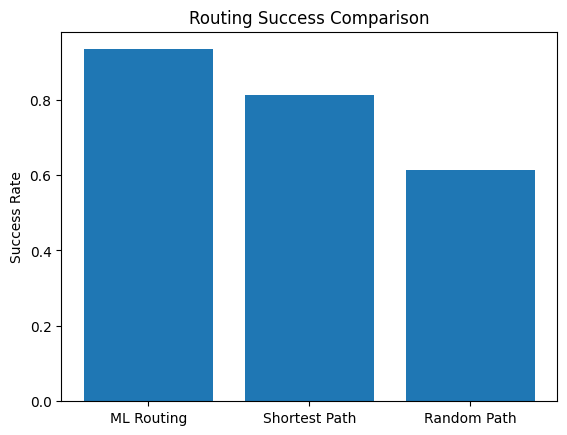

In [20]:
import matplotlib.pyplot as plt

labels = ['ML Routing', 'Shortest Path','Random Path']
values = [
    sum(ml_success)/len(ml_success),
    sum(sp_success)/len(sp_success),
    sum(rand_success)/len(rand_success)
]

plt.bar(labels, values)
plt.title("Routing Success Comparison")
plt.ylabel("Success Rate")
plt.savefig("comparison.png")
plt.show()

In [21]:

plt.savefig("comparison.png")
plt.show()
print("comparison.png saved")

#from google.colab import files
#files.download("comparison.png")

<Figure size 640x480 with 0 Axes>

comparison.png saved


In [22]:
print("\n=== STABILITY TEST ===")

runs = []

for _ in range(5):
    temp_results = []

    for _ in range(200):
        s, d = random.sample(list(G.nodes()), 2)
        paths = list(nx.all_simple_paths(G, s, d, cutoff=5))[:5]

        if len(paths) == 0:
            continue

        df_paths = create_features(paths)

        if len(df_paths) == 0:
            continue

        best_idx, _, _, _ = select_best_path(df_paths)

        prob = rf_model.predict_proba(df_paths.iloc[[best_idx]])[0][1]
        result = 1 if prob > 0.5 else 0
        temp_results.append(result)

    runs.append(sum(temp_results)/len(temp_results))

print("Mean Success Rate:", np.mean(runs))
print("Std Deviation:", np.std(runs))


=== STABILITY TEST ===
Mean Success Rate: 0.9410000000000001
Std Deviation: 0.01562049935181327
